In [189]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import h5py
from PIL import Image
from pathlib import Path
from public_tests import *

In [190]:
def load_dataset():
    current_dir = Path().resolve()
    dataset_dir = (current_dir / ".." / "Optional_Labs" / "W2A2" / "datasets").resolve()
    train_path = dataset_dir / "train_catvnoncat.h5"
    test_path = dataset_dir / "test_catvnoncat.h5"
    with h5py.File(train_path, "r") as f:
        X_train_orig = f["train_set_x"][:]  # (209, 64, 64, 3)
        y_train = f["train_set_y"][:]  # (209,)
    with h5py.File(test_path, "r") as f:
        X_test_orig = f["test_set_x"][:]  # (50, 64, 64, 3)
        y_test = f["test_set_y"][:]  # (50,)
        classes = f["list_classes"][:]  # [b'non-cat' b'cat']
    y_train, y_test = y_train.reshape(1, -1), y_test.reshape(
        1, -1
    )  # (1, 209),  (1, 50)
    return X_train_orig, y_train, X_test_orig, y_test, classes

In [191]:
X_train_orig, y_train, X_test_orig, y_test, classes = load_dataset()
num_px = X_train_orig.shape[1]
print(f"num_px = {num_px}")
X_train = X_train_orig.reshape(
    X_train_orig.shape[0], -1
).T  # Each training set example arranged in its column vector (12288, 209)
X_test = X_test_orig.reshape(
    X_test_orig.shape[0], -1
).T  # Each test set example arranged in its column vector  (12288, 50)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape, classes)

num_px = 64
(12288, 209) (1, 209) (12288, 50) (1, 50) [b'non-cat' b'cat']


1
y = 1. It's a 'cat' picture.


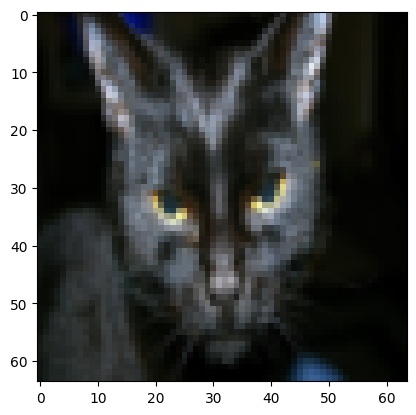

In [192]:
# Example of a picture
index = 25
plt.imshow(X_train[:, index].reshape(num_px, num_px, 3))
y_val = y_train[-1, index].squeeze()
print(y_val)
print(f"y = {y_val}. It's a '{classes[y_val].decode("utf-8")}' picture.")

In [193]:
print(f"Train set X shape = {X_train.shape}")
print(f"Train set y shape = {y_train.shape}")
print(f"Test set X shape = {X_test.shape}")
print(f"Test set y shape = {y_test.shape}")
print(f"classes = \n {classes}")

Train set X shape = (12288, 209)
Train set y shape = (1, 209)
Test set X shape = (12288, 50)
Test set y shape = (1, 50)
classes = 
 [b'non-cat' b'cat']


In [194]:
assert np.all(
    X_train[0:10, 1] == [196, 192, 190, 193, 186, 182, 188, 179, 174, 213]
), "Wrong solution. Use (X.shape[0], -1).T."
assert np.all(
    X_test[0:10, 1] == [115, 110, 111, 137, 129, 129, 155, 146, 145, 159]
), "Wrong solution. Use (X.shape[0], -1).T."

print("train_set_x_flatten shape: " + str(X_train.shape))
print("train_set_y shape: " + str(y_train.shape))
print("test_set_x_flatten shape: " + str(X_test.shape))
print("test_set_y shape: " + str(y_test.shape))

train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)


In [195]:
X_norm_train = X_train / 255.0
X_norm_test = X_test / 255.0

In [196]:
def sigmoid(z):
    """
    Compute the sigmoid of z
    Arguments:
    z -- A scalar or numpy array of any size.
    Return:
    s -- sigmoid(z)
    """
    z = np.asarray(z, dtype=np.float64)
    return np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))

In [197]:
print(f"Sigmoid of [0, 2] = {sigmoid([0, 2])}")
sigmoid_test(sigmoid)
x = np.array([0.5, 0, 2.0])
output = sigmoid(x)
print(output)

Sigmoid of [0, 2] = [0.5        0.88079708]
 All tests passed.
[0.62245933 0.5        0.88079708]


In [198]:
def log_1pexp(z):
    z = np.asarray(z, dtype=np.float64)
    return np.where(z >= 0, z + np.log(1 + np.exp(-z)), np.log(1 + np.exp(z)))

In [199]:
def propagate(w, b, X, Y):
    m = X.shape[1]
    z = w @ X + b
    A = sigmoid(z)
    cost = -Y * z + log_1pexp(z)
    cost = np.sum(cost) / m

    e = A - Y
    dw = (e @ X.T) / m
    db = np.sum(e) / m
    cost = np.squeeze(cost)
    grads = {"dw": dw, "db": db}
    return grads, cost

In [200]:
X = np.array([[1.0, -2.0, -1.0], [3.0, 0.5, -3.2]])
Y = np.array([[1, 1, 0]])
w = np.array([[1.0, 2]])
b = 1.5
grads, cost = propagate(w, b, X, Y)
print(grads, cost)
assert type(grads["dw"]) == np.ndarray
assert grads["dw"].shape == w.shape
assert type(grads["db"]) == np.float64


print("dw = " + str(grads["dw"]))
print("db = " + str(grads["db"]))
print("cost = " + str(cost))

{'dw': array([[ 0.25071532, -0.06604096]]), 'db': np.float64(-0.12500404500439652)} 0.1590053770769241
dw = [[ 0.25071532 -0.06604096]]
db = -0.12500404500439652
cost = 0.1590053770769241


In [201]:
def optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False):
    w = copy.deepcopy(w)
    b = copy.deepcopy(b)
    costs = []
    for i in range(num_iterations):
        grads, cost = propagate(w, b, X, Y)
        dw = grads["dw"]
        db = grads["db"]
        w -= learning_rate * dw
        b -= learning_rate * db
        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"Cost after Iteration {i} : {cost}")
    params = {"w": w, "b": b}
    grads = {"dw": dw, "db": db}
    return params, grads, costs

In [202]:
X = np.array([[1.0, -2.0, -1.0], [3.0, 0.5, -3.2]])
Y = np.array([[1, 1, 0]])
w = np.array([[1.0, 2]])
b = 1.5
params, grads, costs = optimize(
    w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False
)
costs = np.squeeze(costs)
print(f"w = {params["w"]}")
print(f"b = {params["b"]}")
print(f"dw = {grads["dw"]}")
print(f"db = {grads["db"]}")
print(f"Costs = {costs}")

w = [[0.80956046 2.0508202 ]]
b = 1.5948713189708588
dw = [[ 0.17860505 -0.04840656]]
db = -0.08888460336847771
Costs = 0.1590053770769241


In [203]:
def predict(w, b, X):
    m = X.shape[1]
    z = w @ X + b
    A = sigmoid(z)
    return np.where(A > 0.5, 1, 0)

In [204]:
w = np.array([[0.1124579, 0.23106775]])
b = -0.3
X = np.array([[1.0, -1.1, -3.2], [1.2, 2.0, 0.1]])
print("predictions = " + str(predict(w, b, X)))
# predict_test(predict)

predictions = [[1 1 0]]


In [205]:
def model(
    X_train,
    Y_train,
    X_test,
    Y_test,
    num_iterations=2000,
    learning_rate=0.5,
    verbose=False,
):
    w = np.zeros((X_train.shape[0])).reshape(1, -1)
    b = np.zeros(Y_train.shape[0])
    params, grads, costs = optimize(
        w,
        b,
        X_train,
        Y_train,
        num_iterations=num_iterations,
        learning_rate=learning_rate,
        print_cost=verbose,
    )
    w = params["w"]
    b = params["b"]
    Y_pred_train = predict(w, b, X_train)
    Y_pred_test = predict(w, b, X_test)
    if verbose:
        training_accuracy_train = 100 - (np.mean(np.abs(Y_pred_train - Y_train)) * 100)
        training_accuracy_test = 100 - (np.mean(np.abs(Y_pred_test - Y_test)) * 100)
        print(f"Training accuracy : {training_accuracy_train}")
        print(f"Test accuracy : {training_accuracy_test}")
    d = {
        "costs": costs,
        "Y_prediction_train": Y_pred_train,
        "Y_prediction_test": Y_pred_test,
        "w": w,
        "b": b,
        "learning_rate": learning_rate,
        "num_iterations": num_iterations,
    }
    return d

In [206]:
logistic_regression_model = model(
    X_norm_train,
    y_train,
    X_norm_test,
    y_test,
    num_iterations=20000,
    learning_rate=0.005,
    verbose=True,
)

Cost after Iteration 0 : 0.6931471805599453
Cost after Iteration 100 : 0.5845083636993086
Cost after Iteration 200 : 0.46694904094655476
Cost after Iteration 300 : 0.37600686694802077
Cost after Iteration 400 : 0.33146328932825125
Cost after Iteration 500 : 0.30327306747438293
Cost after Iteration 600 : 0.27987958658260487
Cost after Iteration 700 : 0.2600421369258757
Cost after Iteration 800 : 0.2429406846779662
Cost after Iteration 900 : 0.2280042225672607
Cost after Iteration 1000 : 0.2148195137844964
Cost after Iteration 1100 : 0.20307819060644985
Cost after Iteration 1200 : 0.19254427716706862
Cost after Iteration 1300 : 0.18303333796883509
Cost after Iteration 1400 : 0.17439859438448874
Cost after Iteration 1500 : 0.16652139705400332
Cost after Iteration 1600 : 0.15930451829756614
Cost after Iteration 1700 : 0.15266732471296504
Cost after Iteration 1800 : 0.14654223503982342
Cost after Iteration 1900 : 0.1408720757031016
Cost after Iteration 2000 : 0.1356080752591202
Cost after I

True Cat class = cat. Predicted Cat class = non-cat.


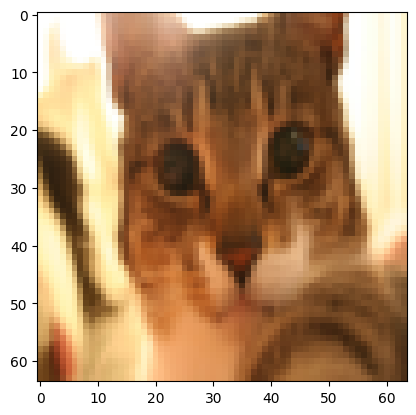

In [220]:
# Example of a picture that was wrongly classified.
index = 11
plt.imshow(X_test[:, index].reshape((num_px, num_px, 3)))
y_index = np.squeeze(y_test[:, index])
true_cat_class = classes[y_index].decode("utf-8")
y_test_index = np.squeeze(logistic_regression_model["Y_prediction_test"][:, index])
predicted_cat_class = classes[y_test_index].decode("utf-8")
print(
    f"True Cat class = {true_cat_class}. Predicted Cat class = {predicted_cat_class}."
)

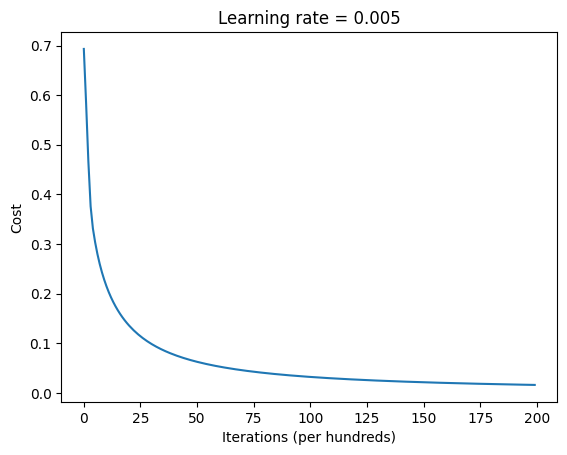

In [ ]:
costs = np.squeeze(logistic_regression_model["costs"])
plt.plot(costs)
plt.ylabel("Cost")
plt.xlabel("Iterations (per hundreds)")
plt.title(f"Learning rate = {logistic_regression_model["learning_rate"]}")
plt.show()

In [ ]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}
for lr in learning_rates:
    print(f"Training the model with learning rate {lr}")
    models[str(lr)] = model(
        X_norm_train,
        y_train,
        X_norm_test,
        y_test,
        num_iterations=1500,
        learning_rate=lr,
        verbose=False,
    )
    print("\n" + "-------------------------------------------------------" + "\n")

Training the model with learning rate 0.01

-------------------------------------------------------

Training the model with learning rate 0.001

-------------------------------------------------------

Training the model with learning rate 0.0001

-------------------------------------------------------



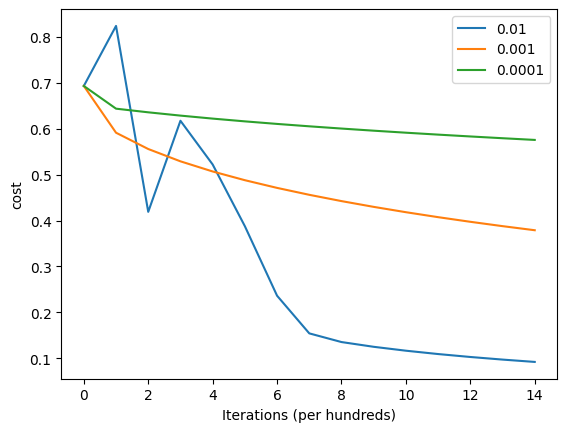

In [ ]:
# Plot cost over iterations for all the learning rates
for lr in learning_rates:
    costs = np.squeeze(models[str(lr)]["costs"])
    learning_rate = models[str(lr)]["learning_rate"]
    plt.plot(costs, label=str(learning_rate))
plt.ylabel("cost")
plt.xlabel("Iterations (per hundreds)")
plt.legend()
plt.show()

Prediction = cat


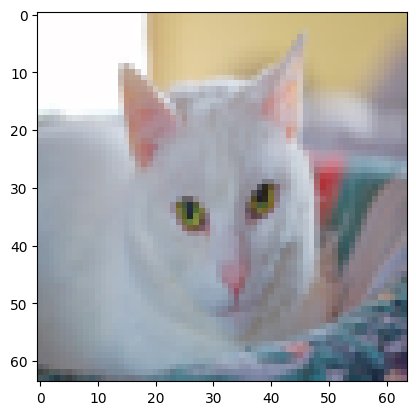

In [221]:
current_dir = Path().resolve()
image = (
    current_dir / ".." / "Optional_Labs" / "W2A2" / "images" / "my_image2.jpg"
).resolve()
image = np.array(Image.open(image).convert("RGB").resize((num_px, num_px)))
plt.imshow(image)
image_norm = image.reshape(-1, 1) / 255.0
my_predicted_image = predict(
    logistic_regression_model["w"], logistic_regression_model["b"], image_norm
)
y_image_pred = classes[np.squeeze(my_predicted_image)]
print(f"Prediction = {y_image_pred.decode("utf-8")}")